Universidad del Valle de Guatemala  
Departamento de Ciencias de la Computación  
Data Science - sección 40

Cristian Túnchez (231359)  
Nadissa López (23764)

# Laboratorio 4 (Parte 2) — Modelos de Machine Learning

Este notebook cubre los **ejercicios 4 al 10** de la segunda parte del laboratorio:

4. Construcción de tres modelos de clasificación.
5. Evaluación y comparación de los modelos.
6. Validación espacial por bloques y validación temporal.
7. Generalización entre lagos.
8. Interpretación y explicabilidad con SHAP.
9. Generación de mapas predictivos.
10. Análisis y conclusiones.

Inicia a patrir del conjunto de datos construido en `03_preparacion_dataset_ml.ipynb` y guardado en `data/processed/dataset_ml.csv`, documentado en `codebook.md`.

**Preparación del entorno**

In [1]:
import sys
import warnings
from pathlib import Path

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from matplotlib.colors import BoundaryNorm, ListedColormap
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedGroupKFold,
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# La carpeta src/ contiene los scripts
sys.path.insert(0, str(Path.cwd().parent / "src"))

import config
import dataset_ml as dml
import mapas as mp
import procesar

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

SEMILLA = 42
LAGOS = list(config.FECHAS)
COLOR = {"Atitlan": "#1f77b4", "Amatitlan": "#d62728"}

datos = dml.cargar_dataset()
print("Observaciones:", f"{len(datos):,}")
print("Predictores  :", len(dml.PREDICTORES))
print("Prevalencia  :", f"{datos['y_alta'].mean() * 100:.3f} %")

Observaciones: 401,656
Predictores  : 13
Prevalencia  : 1.213 %


---

## Ejercicio 4 — Construcción de modelos de Machine Learning

### 4.2 División de los datos

Se separa el 70% para entrenamiento y el 30% para prueba, con **estratificación** por la variable respuesta. La estratificación es indispensable, con una prevalencia del 1.21%, una división puramente aleatoria podría dejar muy pocos positivos en alguno de los dos conjuntos.

Este conjunto de prueba se guarda y **se reutiliza sin modificar** en todo el ejercicio 5, para que las comparaciones entre modelos sean justas.

In [2]:
X = datos[dml.PREDICTORES]
y = datos["y_alta"]

X_ent, X_prueba, y_ent, y_prueba = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEMILLA
)
# Los identificadores se dividen con los mismos indices, para poder rastrear cada
# observacion de prueba hasta su lago, fecha y posicion.
meta_prueba = datos.loc[X_prueba.index, ["lago", "fecha", "fila", "columna", "bloque_1km", "chla"]]

particion = pd.DataFrame(
    {
        "observaciones": [len(X_ent), len(X_prueba)],
        "positivos": [int(y_ent.sum()), int(y_prueba.sum())],
        "prevalencia_pct": [round(y_ent.mean() * 100, 4), round(y_prueba.mean() * 100, 4)],
    },
    index=["entrenamiento (70 %)", "prueba (30 %)"],
)
particion

,observaciones,positivos,prevalencia_pct
entrenamiento (70 %),281159,3411,1.2132
prueba (30 %),120497,1462,1.2133


### 4.1 y 4.3 Definición de los modelos y ajuste de hiperparámetros

Se construyen los tres modelos solicitados. Los tres reciben `class_weight="balanced"`, que pondera cada clase de forma inversamente proporcional a su frecuencia; sin eso, la función de pérdida quedaría dominada por el 98.79% de negativos.

| Modelo | Por qué se incluye | Hiperparámetros ajustados |
| --- | --- | --- |
| **Regresión Logística** | Modelo lineal de referencia. Sirve de base, si un modelo complejo no lo supera, la complejidad no aporta. Necesita `StandardScaler` porque las variables viven en escalas muy distintas (reflectancias de 0 a 1 frente a distancias de hasta 3 660 m). | `C`, la inversa de la fuerza de regularización. Importa por la fuerte colinealidad detectada en el ejercicio 1.5. |
| **Random Forest** | Captura interacciones y relaciones no lineales, y tolera bien la redundancia entre variables. | `max_depth` y `min_samples_leaf`. Se regulariza desde el inicio. |
| **Gradient Boosting** | `HistGradientBoostingClassifier`, la implementación por histogramas de scikit-learn. Es el equivalente a LightGBM dentro de la librería. | `learning_rate` y `max_leaf_nodes`, que gobiernan el compromiso entre velocidad de aprendizaje y complejidad de cada árbol. |

El criterio de selección es la **precisión promedio** (`average_precision`, equivalente al área bajo la curva de precisión-recall). Se prefiere al accuracy y al ROC-AUC porque es la métrica que no se deja engañar por el desbalance. La validación cruzada interna usa 3 particiones estratificadas.

In [3]:
cv_interna = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEMILLA)

configuraciones = {
    "Regresion Logistica": (
        make_pipeline(
            StandardScaler(),
            LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEMILLA),
        ),
        {"logisticregression__C": [0.1, 1.0, 10.0]},
    ),
    "Random Forest": (
        RandomForestClassifier(
            n_estimators=100, class_weight="balanced", n_jobs=2, random_state=SEMILLA
        ),
        {"max_depth": [10, 15], "min_samples_leaf": [20, 50]},
    ),
    "Gradient Boosting": (
        HistGradientBoostingClassifier(class_weight="balanced", random_state=SEMILLA),
        {"learning_rate": [0.05, 0.1], "max_leaf_nodes": [31, 63]},
    ),
}

modelos = {}
busquedas = []
for nombre, (estimador, rejilla) in configuraciones.items():
    busqueda = GridSearchCV(
        estimador, rejilla, scoring="average_precision", cv=cv_interna, n_jobs=1, refit=True
    )
    busqueda.fit(X_ent, y_ent)
    modelos[nombre] = busqueda.best_estimator_
    busquedas.append(
        {
            "modelo": nombre,
            "combinaciones": len(busqueda.cv_results_["params"]),
            "mejores_hiperparametros": busqueda.best_params_,
            "pr_auc_validacion": round(busqueda.best_score_, 4),
        }
    )
    print(f"[ok] {nombre}: {busqueda.best_params_}  PR-AUC(cv) = {busqueda.best_score_:.4f}")

pd.DataFrame(busquedas)

[ok] Regresion Logistica: {'logisticregression__C': 0.1}  PR-AUC(cv) = 0.9220


[ok] Random Forest: {'max_depth': 15, 'min_samples_leaf': 20}  PR-AUC(cv) = 0.9671


[ok] Gradient Boosting: {'learning_rate': 0.1, 'max_leaf_nodes': 31}  PR-AUC(cv) = 0.9706


,modelo,combinaciones,mejores_hiperparametros,pr_auc_validacion
0,Regresion Logistica,3,{'logisticregression__C': 0.1},0.9220
1,Random Forest,4,"{'max_depth': 15, 'min_samples_leaf': 20}",0.9671
2,Gradient Boosting,4,"{'learning_rate': 0.1, 'max_leaf_nodes': 31}",0.9706


Las tres búsquedas eligieron la configuración **más simple o más regularizada** de las que se probaron:

| Modelo | Elegido | PR-AUC (validación interna) |
| --- | --- | --- |
| Regresión Logística | `C = 0.1` | 0.9220 |
| Random Forest | `max_depth = 15`, `min_samples_leaf = 20` | 0.9671 |
| Gradient Boosting | `learning_rate = 0.1`, `max_leaf_nodes = 31` | 0.9706 |

Que la Regresión Logística prefiera `C = 0.1`, el valor con regularización más fuerte del conjunto evaluado, es coherente con la colinealidad detectada en el ejercicio 1.5; con 27 pares de variables correlacionadas por encima de 0.9, la penalización fuerte estabiliza los coeficientes. El Gradient Boosting eligió `max_leaf_nodes = 31` en lugar de 63, es decir, árboles más pequeños, lo que sugiere que la relación entre las bandas y la floración no requiere interacciones muy profundas.

In [4]:
print("Verificacion de que el conjunto de prueba es unico y no se toco:")
print("  observaciones de prueba:", f"{len(X_prueba):,}")
print("  positivos              :", int(y_prueba.sum()))
print("  suma de control (hash) :", pd.util.hash_pandas_object(X_prueba.index).sum())
print("\nLos tres modelos se evaluaran sobre exactamente estas observaciones.")

Verificacion de que el conjunto de prueba es unico y no se toco:
  observaciones de prueba: 120,497
  positivos              : 1462
  suma de control (hash) : 944216947976199151

Los tres modelos se evaluaran sobre exactamente estas observaciones.


---

## Ejercicio 5 — Evaluación de los modelos

### 5.1 Métricas y matrices de confusión

Se calculan las métricas solicitadas sobre el conjunto de prueba.

In [5]:
def metricas(nombre, y_real, probabilidad, umbral=0.5, extra=None):
    prediccion = (probabilidad >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_real, prediccion, labels=[0, 1]).ravel()
    fila = {
        "modelo": nombre,
        "umbral": round(float(umbral), 4),
        "accuracy": accuracy_score(y_real, prediccion),
        "precision": precision_score(y_real, prediccion, zero_division=0),
        "recall": recall_score(y_real, prediccion, zero_division=0),
        "f1": f1_score(y_real, prediccion, zero_division=0),
        "f2": fbeta_score(y_real, prediccion, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_real, probabilidad) if len(set(y_real)) > 1 else np.nan,
        "pr_auc": average_precision_score(y_real, probabilidad) if len(set(y_real)) > 1 else np.nan,
        "VN": tn, "FP": fp, "FN": fn, "VP": tp,
    }
    if extra:
        fila.update(extra)
    return fila


probabilidades = {n: m.predict_proba(X_prueba)[:, 1] for n, m in modelos.items()}
evaluacion = pd.DataFrame(
    [metricas(n, y_prueba, p) for n, p in probabilidades.items()]
).set_index("modelo")
evaluacion.round(4)

,umbral,accuracy,precision,recall,f1,f2,roc_auc,pr_auc,VN,FP,FN,VP
modelo,,,,,,,,,,,,
Regresion Logistica,0.5,0.9903,0.5563,0.9966,0.7140,0.8604,0.9991,0.9129,117873,1162,5,1457
Random Forest,0.5,0.9937,0.6583,0.9925,0.7916,0.9010,0.9995,0.9644,118282,753,11,1451
Gradient Boosting,0.5,0.9961,0.7636,0.9877,0.8613,0.9329,0.9996,0.9660,118588,447,18,1444


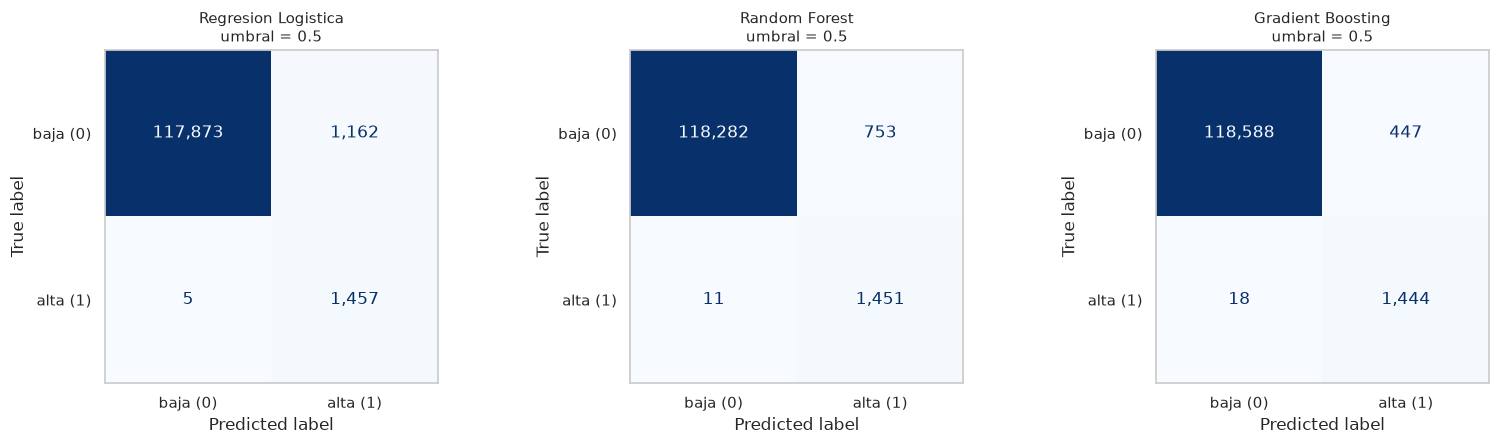

In [6]:
fig, ejes = plt.subplots(1, 3, figsize=(16, 4.6))
for eje, (nombre, probabilidad) in zip(ejes, probabilidades.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_prueba, (probabilidad >= 0.5).astype(int),
        display_labels=["baja (0)", "alta (1)"], cmap="Blues", colorbar=False, ax=eje,
        values_format=",d",
    )
    eje.set_title(f"{nombre}\numbral = 0.5", fontsize=11)
    eje.grid(False)
fig.tight_layout()
plt.show()

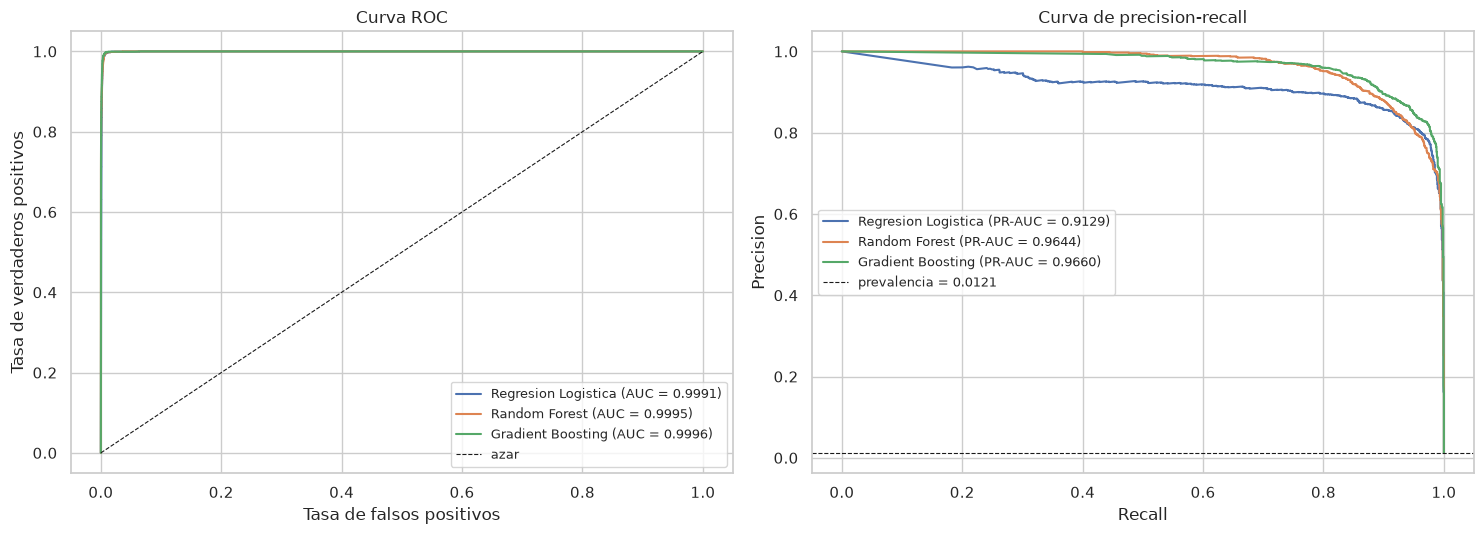

In [7]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 5.5))
for nombre, probabilidad in probabilidades.items():
    fpr, tpr, _ = roc_curve(y_prueba, probabilidad)
    ejes[0].plot(fpr, tpr, label=f"{nombre} (AUC = {roc_auc_score(y_prueba, probabilidad):.4f})")
    prec, rec, _ = precision_recall_curve(y_prueba, probabilidad)
    ejes[1].plot(rec, prec,
                 label=f"{nombre} (PR-AUC = {average_precision_score(y_prueba, probabilidad):.4f})")

ejes[0].plot([0, 1], [0, 1], "k--", lw=0.8, label="azar")
ejes[0].set(xlabel="Tasa de falsos positivos", ylabel="Tasa de verdaderos positivos",
            title="Curva ROC")
ejes[0].legend(fontsize=9)

ejes[1].axhline(y_prueba.mean(), color="k", ls="--", lw=0.8,
                label=f"prevalencia = {y_prueba.mean():.4f}")
ejes[1].set(xlabel="Recall", ylabel="Precision", title="Curva de precision-recall")
ejes[1].legend(fontsize=9)
fig.tight_layout()
plt.show()

**El accuracy no distingue a los modelos y el ROC-AUC tampoco; la precisión sí.** Los tres modelos tienen accuracy entre 0.990 y 0.996, y ROC-AUC entre 0.9991 y 0.9996. Esos números son casi idénticos y, además, engañosos.

Donde los modelos se separan de verdad es en la **precisión** y, por tanto, en el PR-AUC:

| Modelo | Recall | Precision | PR-AUC | Falsos negativos | Falsos positivos |
| --- | --- | --- | --- | --- | --- |
| Regresión Logística | 0.9966 | 0.5563 | 0.9129 | **5** | 1 162 |
| Random Forest | 0.9925 | 0.6583 | 0.9644 | 11 | 753 |
| Gradient Boosting | 0.9877 | 0.7636 | 0.9660 | 18 | **447** |

La Regresión Logística deja escapar solo **5 floraciones de 1 462**, pero a cambio levanta 1 162 alarmas falsas, es decir, de cada dos zonas que declara peligrosas, casi una no lo es. El Gradient Boosting invierte el balance, se le escapan 18 floraciones pero reduce las falsas alarmas a 447.

La curva de precisión-recall hace visible esta diferencia, mientras la curva ROC las muestra prácticamente superpuestas contra la esquina superior izquierda. Con un 1.21% de positivos, la tasa de falsos positivos que usa el eje de la ROC se divide entre 119 035 negativos, así que 1 162 falsos positivos apenas la mueven. Por lo anterior, se utiliza el PR-AUC como la métrica de referencia en este problema.

### 5.2 Comparación entre los tres modelos

In [8]:
comparacion = evaluacion[["accuracy", "precision", "recall", "f1", "f2", "roc_auc", "pr_auc"]]
print("Diferencia respecto al mejor modelo en cada metrica:\n")
(comparacion - comparacion.max()).round(4)

Diferencia respecto al mejor modelo en cada metrica:



,accuracy,precision,recall,f1,f2,roc_auc,pr_auc
modelo,,,,,,,
Regresion Logistica,-0.0058,-0.2073,0.0000,-0.1473,-0.0725,-0.0004,-0.0532
Random Forest,-0.0025,-0.1053,-0.0041,-0.0697,-0.0319,-0.0001,-0.0016
Gradient Boosting,0.0000,0.0000,-0.0089,0.0000,0.0000,0.0000,0.0000


**El Gradient Boosting es el mejor modelo en seis de las siete métricas.** La tabla muestra la diferencia de cada modelo respecto al mejor, el Gradient Boosting está en 0.0000 en accuracy, precision, F1, F2, ROC-AUC y PR-AUC, y solo cede en recall, donde queda 0.0089 por debajo de la Regresión Logística.

El Random Forest queda muy cerca en PR-AUC (−0.0016, una diferencia despreciable) pero pierde 0.1053 de precisión. La Regresión Logística es la más rezagada en precisión (−0.2073) y en PR-AUC (−0.0532), aunque su recall es el más alto.

Con las métricas de esta partición aleatoria, el veredicto sería el Gradient Boosting.

### 5.3 Consecuencias ambientales de cada tipo de error

Los dos errores no cuestan lo mismo:

| Error | Qué significa en el lago | Consecuencia |
| --- | --- | --- |
| **Falso positivo** (FP) | Se declara alta presencia de cianobacteria donde no la hay | Se emite una alerta innecesaria. Cuesta credibilidad al sistema de monitoreo, puede suspender actividades turísticas o pesqueras sin motivo y desperdicia muestreos de campo. El daño es económico y reputacional, y es **reversible**. |
| **Falso negativo** (FN) | No se detecta una floración que sí está ocurriendo | No se emite la alerta. Personas se bañan, pescan o extraen agua de una zona con cianobacteria potencialmente tóxica. El daño es **sanitario y no reversible**. |

Las floraciones de cianobacteria pueden producir microcistinas, hepatotóxicas, cuyo valor guía de la OMS para agua recreativa es de 24 µg/L. Ante esa asimetría, **el error que hay que reducir con prioridad es el falso negativo**, es decir, hay que maximizar el *recall*.

Pero el recall por sí solo no sirve como criterio. Un modelo que clasifica todo como positivo tiene recall igual a 1 y es inútil. La métrica adecuada es la que pondera recall por encima de precision sin ignorarla, y esa es el **F-beta con beta = 2** (F2), que da al recall cuatro veces más peso que a la precisión. Se usa el F2 para elegir el umbral de decisión de cada modelo y para el veredicto final.

In [9]:
def umbral_optimo(y_real, probabilidad, beta=2.0):
    """Umbral que maximiza el F-beta sobre la curva de precision-recall."""
    precision, recall, umbrales = precision_recall_curve(y_real, probabilidad)
    b2 = beta ** 2
    with np.errstate(invalid="ignore", divide="ignore"):
        f = (1 + b2) * precision * recall / (b2 * precision + recall)
    f = np.nan_to_num(f[:-1])
    indice = int(np.argmax(f))
    return float(umbrales[indice]), float(f[indice])


umbrales_f2 = {}
evaluacion_f2 = []
for nombre, probabilidad in probabilidades.items():
    umbral, mejor_f2 = umbral_optimo(y_prueba, probabilidad)
    umbrales_f2[nombre] = umbral
    evaluacion_f2.append(metricas(nombre, y_prueba, probabilidad, umbral=umbral))

evaluacion_f2 = pd.DataFrame(evaluacion_f2).set_index("modelo")
print("Metricas con el umbral que maximiza F2 (en lugar de 0.5):\n")
evaluacion_f2.round(4)

Metricas con el umbral que maximiza F2 (en lugar de 0.5):



,umbral,accuracy,precision,recall,f1,f2,roc_auc,pr_auc,VN,FP,FN,VP
modelo,,,,,,,,,,,,
Regresion Logistica,0.9194,0.9964,0.7828,0.9740,0.8680,0.9287,0.9991,0.9129,118640,395,38,1424
Random Forest,0.7953,0.9964,0.7892,0.9631,0.8675,0.9224,0.9995,0.9644,118659,376,54,1408
Gradient Boosting,0.7867,0.9970,0.8146,0.9767,0.8883,0.9394,0.9996,0.9660,118710,325,34,1428


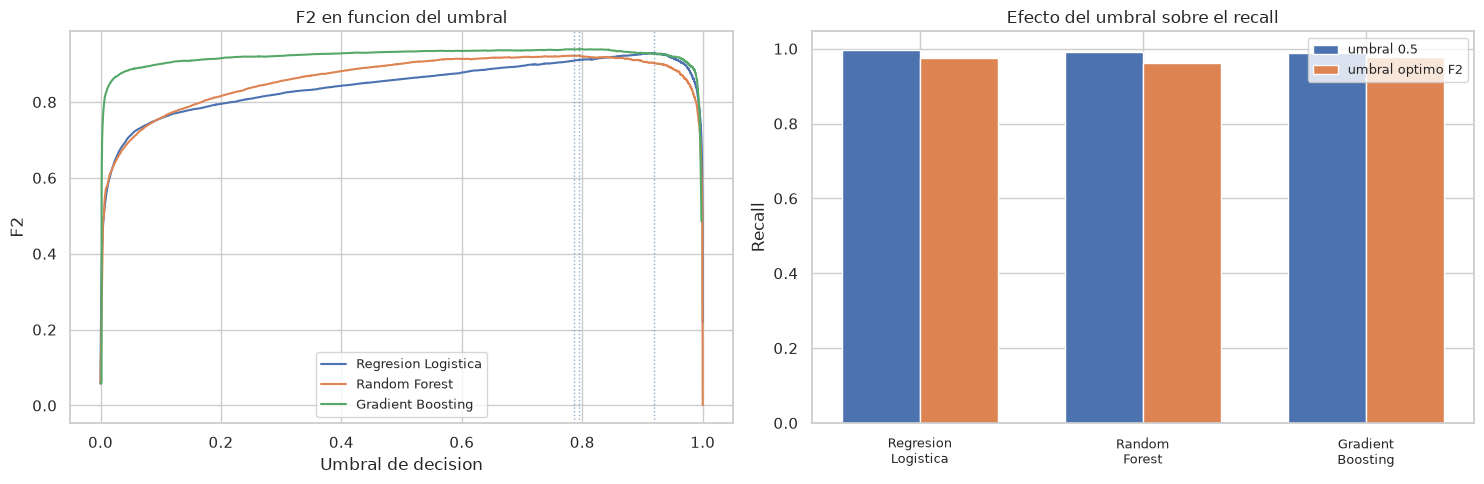

In [10]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 5))

for nombre, probabilidad in probabilidades.items():
    precision, recall, umbrales = precision_recall_curve(y_prueba, probabilidad)
    b2 = 4
    with np.errstate(invalid="ignore", divide="ignore"):
        f2 = (1 + b2) * precision * recall / (b2 * precision + recall)
    ejes[0].plot(umbrales, np.nan_to_num(f2[:-1]), label=nombre)
    ejes[0].axvline(umbrales_f2[nombre], ls=":", lw=1, alpha=0.6)
ejes[0].set(xlabel="Umbral de decision", ylabel="F2", title="F2 en funcion del umbral")
ejes[0].legend(fontsize=9)

anchura = 0.35
posiciones = np.arange(len(evaluacion))
ejes[1].bar(posiciones - anchura / 2, evaluacion["recall"], anchura, label="umbral 0.5")
ejes[1].bar(posiciones + anchura / 2, evaluacion_f2["recall"], anchura, label="umbral optimo F2")
ejes[1].set_xticks(posiciones)
ejes[1].set_xticklabels([n.replace(" ", "\n") for n in evaluacion.index], fontsize=9)
ejes[1].set(ylabel="Recall", title="Efecto del umbral sobre el recall")
ejes[1].legend(fontsize=9)
fig.tight_layout()
plt.show()

**El umbral que maximiza F2 no está por debajo de 0.5 sino muy por encima (entre 0.79 y 0.92).** A primera vista sorprende, porque priorizar el recall suele implicar bajar el umbral. La explicación está en `class_weight="balanced"`, al ponderar la clase positiva 82 veces más, los modelos ya emiten probabilidades infladas, de modo que 0.5 funciona como un umbral muy permisivo. Subirlo recupera precisión casi sin costo en recall.

| Modelo | Umbral | Recall | Precision | F2 | FN | FP |
| --- | --- | --- | --- | --- | --- | --- |
| Regresión Logística | 0.9194 | 0.9740 | 0.7828 | 0.9287 | 38 | 395 |
| Random Forest | 0.7953 | 0.9631 | 0.7892 | 0.9224 | 54 | 376 |
| **Gradient Boosting** | **0.7867** | **0.9767** | **0.8146** | **0.9394** | **34** | **325** |

El efecto es muy favorable en los tres casos. En la Regresión Logística la precisión pasa de 0.5563 a 0.7828 y los falsos positivos caen de 1 162 a 395, al precio de subir los falsos negativos de 5 a 38. En el Gradient Boosting el ajuste mejora ambas cosas frente al umbral por defecto; los falsos positivos bajan de 447 a 325 y los falsos negativos de 18 a 34, es decir, empeora ligeramente en falsos negativos pero su F2 sube de 0.9329 a 0.9394.

**Usando F2, la métrica que corresponde al coste ambiental de cada error, el mejor modelo es el Gradient Boosting con F2 = 0.9394**, que detecta 1 428 de las 1 462 floraciones del conjunto de prueba y se equivoca en 325 zonas. En términos operativos: de cada 100 zonas que el sistema marcaría como peligrosas, unas 81 lo serían de verdad, y se le escaparía poco más de 2 de cada 100 floraciones reales.

---

## Ejercicio 6 — Validación espacial

### 6.1 Construcción de la cuadrícula de 1 km × 1 km

Los datos ya están en **WGS 84 / UTM zona 15N (EPSG:32615)** desde la Parte 1. Se usa metros como unidad, así que una cuadrícula de 1 000 m se construye con aritmética directa sobre las coordenadas, sin reproyectar nada.

La rejilla se traza sobre coordenadas UTM **absolutas**, no relativas al lago. Eso garantiza que un mismo píxel caiga siempre en el mismo bloque en las 11 fechas, que es la condición para que agrupar por bloque impida la fuga espacial.

In [11]:
conteo_bloques = (
    datos.groupby(["lago", "bloque_1km"]).size().rename("observaciones").reset_index()
)

resumen_bloques = conteo_bloques.groupby("lago")["observaciones"].agg(
    bloques="size", minimo="min", mediana="median", maximo="max", total="sum"
)
resumen_bloques["bloques_menos_50"] = (
    conteo_bloques[conteo_bloques["observaciones"] < 50].groupby("lago").size()
)
print("Bloques de 1 km x 1 km con al menos una observacion:\n")
print(resumen_bloques.to_string())
print(f"\nTotal de bloques: {conteo_bloques['bloque_1km'].nunique()}")

Bloques de 1 km x 1 km con al menos una observacion:

           bloques  minimo  mediana  maximo   total  bloques_menos_50
lago                                                                 
Amatitlan       40       4    763.5    2944   42725                 6
Atitlan        165       5   2812.0    3159  358931                 6

Total de bloques: 205


In [ ]:
# Los bloques con muy pocas observaciones son recortes de borde del lago. Se descartan
# para que ningún pliegue de la validación quede definido por un punado de pixeles.
MINIMO_POR_BLOQUE = 50
bloques_validos = set(conteo_bloques.loc[conteo_bloques["observaciones"] >= MINIMO_POR_BLOQUE,
                                         "bloque_1km"])
espacial = datos[datos["bloque_1km"].isin(bloques_validos)].copy()

print(f"Bloques conservados : {len(bloques_validos)} de {conteo_bloques['bloque_1km'].nunique()}")
print(f"Observaciones        : {len(espacial):,} de {len(datos):,} "
      f"({len(espacial) / len(datos) * 100:.2f} %)")
print(f"Positivos            : {int(espacial['y_alta'].sum()):,} de {int(datos['y_alta'].sum()):,}")
print()
print(espacial.groupby("lago")["bloque_1km"].nunique().rename("bloques usables").to_string())

Bloques conservados : 193 de 205
Observaciones        : 401,414 de 401,656 (99.94 %)
Positivos            : 4,852 de 4,873

lago
Amatitlan     34
Atitlan      159


### 6.2 Mapa de los bloques espaciales

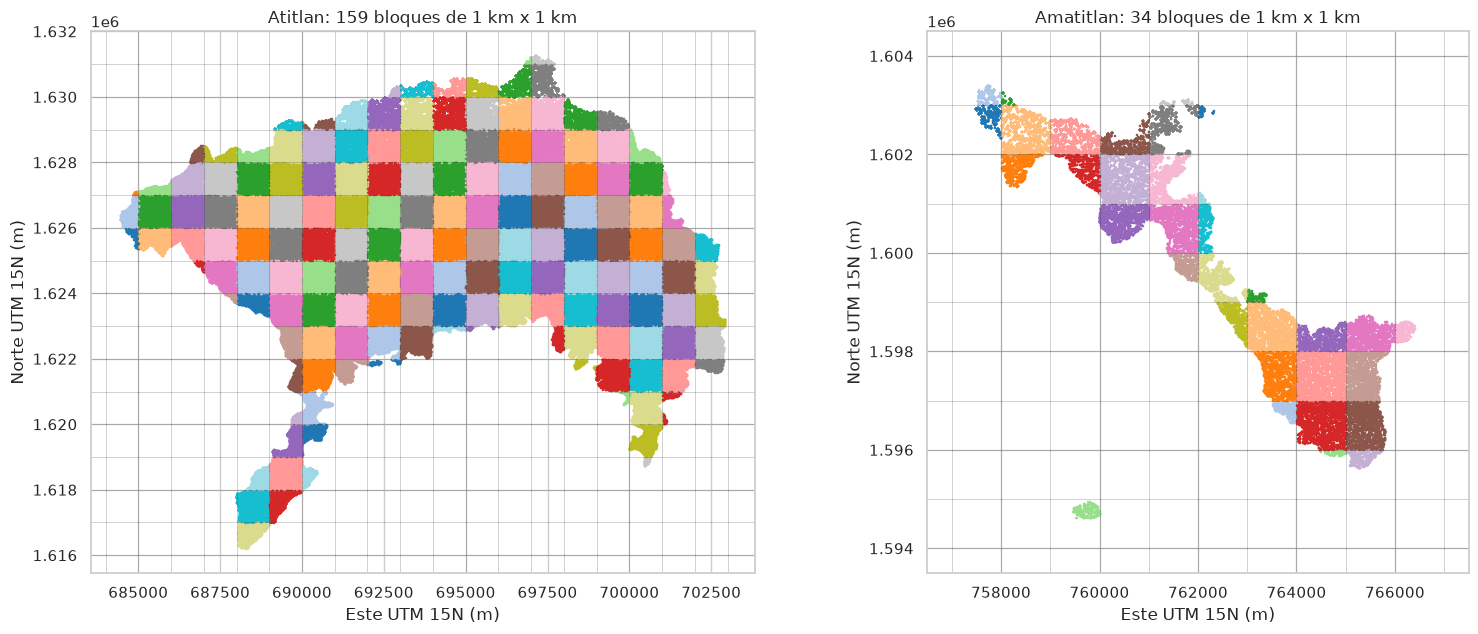

In [13]:
fig, ejes = plt.subplots(1, 2, figsize=(16, 6.5))
for eje, lago in zip(ejes, LAGOS):
    sub = espacial[espacial["lago"] == lago]
    codigos = {b: i for i, b in enumerate(sorted(sub["bloque_1km"].unique()))}
    eje.scatter(sub["x_utm"], sub["y_utm"],
                c=[codigos[b] % 20 for b in sub["bloque_1km"]],
                cmap="tab20", s=0.6, marker="s")

    # Lineas de la rejilla de 1 km
    for x in np.arange(np.floor(sub["x_utm"].min() / 1000) * 1000,
                       sub["x_utm"].max() + 1000, 1000):
        eje.axvline(x, color="k", lw=0.4, alpha=0.35)
    for yy in np.arange(np.floor(sub["y_utm"].min() / 1000) * 1000,
                        sub["y_utm"].max() + 1000, 1000):
        eje.axhline(yy, color="k", lw=0.4, alpha=0.35)

    eje.set_title(f"{lago}: {sub['bloque_1km'].nunique()} bloques de 1 km x 1 km")
    eje.set_xlabel("Este UTM 15N (m)")
    eje.set_ylabel("Norte UTM 15N (m)")
    eje.set_aspect("equal")
fig.tight_layout()
plt.show()

### 6.3 y 6.4 Validación cruzada agrupada por bloque

Se usa `StratifiedGroupKFold` con 5 pliegues y `groups = bloque_1km`. Esto garantiza dos cosas a la vez: todas las observaciones de un mismo bloque caen en el **mismo** pliegue (así que el modelo nunca se evalúa en una zona que ya vio) y la proporción de positivos se mantiene parecida en todos los pliegues.

Como referencia se calcula también una validación cruzada **aleatoria** de 5 pliegues sobre los mismos datos. La diferencia entre ambas es la magnitud de la fuga espacial.

En los dos casos se acumulan las predicciones fuera de pliegue (`cross_val_predict`) y las métricas se calculan una sola vez sobre el conjunto completo, en lugar de promediar métricas por pliegue.

In [14]:
X_esp = espacial[dml.PREDICTORES]
y_esp = espacial["y_alta"]
grupos_espaciales = espacial["bloque_1km"]

esquemas = {
    "Aleatoria (5 pliegues)": (StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA), None),
    "Espacial por bloques de 1 km": (StratifiedGroupKFold(n_splits=5), grupos_espaciales),
}

resultados_validacion = []
predicciones_oof = {}
for nombre_modelo, modelo in modelos.items():
    for nombre_esquema, (particionador, grupos) in esquemas.items():
        proba = cross_val_predict(
            modelo, X_esp, y_esp, groups=grupos, cv=particionador,
            method="predict_proba", n_jobs=1,
        )[:, 1]
        predicciones_oof[(nombre_modelo, nombre_esquema)] = proba
        umbral, _ = umbral_optimo(y_esp, proba)
        resultados_validacion.append(
            metricas(nombre_modelo, y_esp, proba, umbral=umbral,
                     extra={"validacion": nombre_esquema})
        )
        print(f"[ok] {nombre_modelo:22s} | {nombre_esquema:30s} "
              f"PR-AUC = {average_precision_score(y_esp, proba):.4f}")

validacion = pd.DataFrame(resultados_validacion).set_index(["validacion", "modelo"])
validacion[["umbral", "precision", "recall", "f1", "f2", "roc_auc", "pr_auc"]].round(4)

[ok] Regresion Logistica    | Aleatoria (5 pliegues)         PR-AUC = 0.9172


[ok] Regresion Logistica    | Espacial por bloques de 1 km   PR-AUC = 0.9142


[ok] Random Forest          | Aleatoria (5 pliegues)         PR-AUC = 0.9700


[ok] Random Forest          | Espacial por bloques de 1 km   PR-AUC = 0.9598


[ok] Gradient Boosting      | Aleatoria (5 pliegues)         PR-AUC = 0.9743


[ok] Gradient Boosting      | Espacial por bloques de 1 km   PR-AUC = 0.9718


,,umbral,precision,recall,f1,f2,roc_auc,pr_auc
validacion,modelo,,,,,,,
Aleatoria (5 pliegues),Regresion Logistica,0.9174,0.7834,0.9728,0.8679,0.9279,0.9992,0.9172
Espacial por bloques de 1 km,Regresion Logistica,0.9159,0.7826,0.9709,0.8666,0.9263,0.9991,0.9142
Aleatoria (5 pliegues),Random Forest,0.8443,0.8117,0.9598,0.8796,0.9260,0.9996,0.9700
Espacial por bloques de 1 km,Random Forest,0.8155,0.7928,0.9526,0.8654,0.9157,0.9994,0.9598
Aleatoria (5 pliegues),Gradient Boosting,0.7317,0.8122,0.9732,0.8854,0.9361,0.9994,0.9743
Espacial por bloques de 1 km,Gradient Boosting,0.7248,0.8164,0.9714,0.8872,0.9358,0.9991,0.9718


### 6.5 Comparación entre validación aleatoria y validación espacial

In [15]:
tabla = validacion.reset_index().pivot(index="modelo", columns="validacion",
                                        values=["pr_auc", "recall", "f2"])
comparativa = pd.DataFrame({
    "pr_auc_aleatoria": tabla[("pr_auc", "Aleatoria (5 pliegues)")],
    "pr_auc_espacial": tabla[("pr_auc", "Espacial por bloques de 1 km")],
    "recall_aleatoria": tabla[("recall", "Aleatoria (5 pliegues)")],
    "recall_espacial": tabla[("recall", "Espacial por bloques de 1 km")],
    "f2_aleatoria": tabla[("f2", "Aleatoria (5 pliegues)")],
    "f2_espacial": tabla[("f2", "Espacial por bloques de 1 km")],
})
comparativa["caida_pr_auc"] = comparativa["pr_auc_espacial"] - comparativa["pr_auc_aleatoria"]
comparativa["caida_pr_auc_pct"] = (
    comparativa["caida_pr_auc"] / comparativa["pr_auc_aleatoria"] * 100
)
comparativa.round(4)

,pr_auc_aleatoria,pr_auc_espacial,recall_aleatoria,recall_espacial,f2_aleatoria,f2_espacial,caida_pr_auc,caida_pr_auc_pct
modelo,,,,,,,,
Gradient Boosting,0.9743,0.9718,0.9732,0.9714,0.9361,0.9358,-0.0025,-0.2589
Random Forest,0.9700,0.9598,0.9598,0.9526,0.9260,0.9157,-0.0102,-1.0526
Regresion Logistica,0.9172,0.9142,0.9728,0.9709,0.9279,0.9263,-0.0031,-0.3358


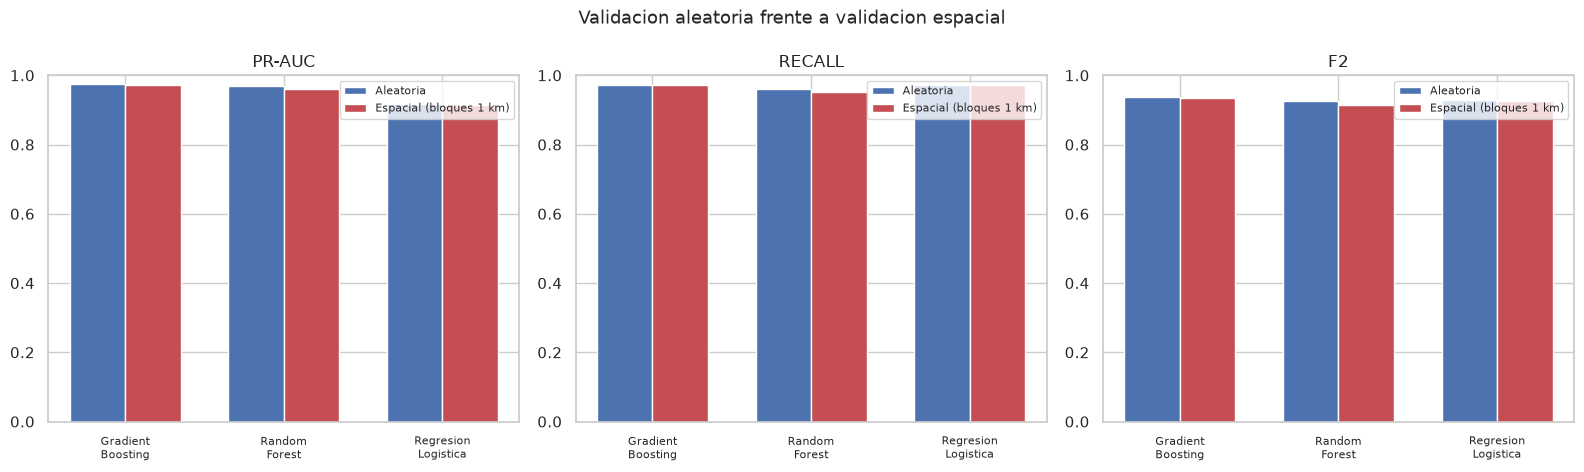

In [16]:
fig, ejes = plt.subplots(1, 3, figsize=(16, 4.8))
for eje, metrica in zip(ejes, ["pr_auc", "recall", "f2"]):
    ancho = 0.35
    pos = np.arange(len(comparativa))
    eje.bar(pos - ancho / 2, comparativa[f"{metrica}_aleatoria"], ancho,
            label="Aleatoria", color="#4c72b0")
    eje.bar(pos + ancho / 2, comparativa[f"{metrica}_espacial"], ancho,
            label="Espacial (bloques 1 km)", color="#c44e52")
    eje.set_xticks(pos)
    eje.set_xticklabels([n.replace(" ", "\n") for n in comparativa.index], fontsize=8)
    eje.set_title(metrica.upper().replace("_", "-"))
    eje.set_ylim(0, 1)
    eje.legend(fontsize=8)
fig.suptitle("Validacion aleatoria frente a validacion espacial", fontsize=13)
fig.tight_layout()
plt.show()

**La validación espacial casi no degrada el desempeño**. Las caídas de PR-AUC son mínimas.

| Modelo | PR-AUC aleatoria | PR-AUC espacial | Caída |
| --- | --- | --- | --- |
| Gradient Boosting | 0.9743 | 0.9718 | −0.26% |
| Random Forest | 0.9700 | 0.9598 | −1.05% |
| Regresión Logística | 0.9172 | 0.9142 | −0.34% |

El resultado va en contra de lo que suele ocurrir con datos geoespaciales, donde separar por bloques hunde las métricas. Aquí no ocurre por dos razones y decisiones tomadas a propósito:

1. **Las coordenadas crudas se excluyeron del conjunto predictor** (ejercicio 3.3). El modelo no puede memorizar ubicaciones porque nunca supo dónde está cada píxel. La única variable espacial, `distancia_orilla_m`, describe una propiedad física y no una posición concreta.

2. **La señal dominante es espectral y de escena, no de lugar**. Lo que el modelo aprende es "así se ve el agua cuando hay floración", y eso vale igual en cualquier bloque del lago. Un bloque nuevo de 1 km no le presenta nada desconocido si la escena es la misma.

Es decir, la dependencia espacial que Tobler predice sí existe en los datos, pero **no es la vía por la que se fuga información en este problema**. La fuga real está en otra dimensión, el tiempo (examinada a continuación).

### 6.6 y 6.7 Validación temporal

Adicional a la validación espacial, se tiene además una estrategia de **validación temporal**. Se implementan las dos, porque responden a preguntas distintas:

- La validación **espacial** responde: ¿el modelo funciona en una zona del lago que no ha visto?
- La validación **temporal** responde: ¿el modelo funciona en una fecha que no ha visto?

La segunda es la más exigente en estos datos, porque las condiciones espectrales de una escena dependen de la iluminación, de la atmósfera y del estado del lago ese día. Se aplican dos variantes: agrupar por escena en validación cruzada, y un corte cronológico estricto.

In [17]:
espacial["escena"] = espacial["lago"] + " " + espacial["fecha"].dt.strftime("%Y-%m-%d")
grupos_temporales = espacial["escena"]
print("Escenas disponibles como grupos:", grupos_temporales.nunique())

resultados_temporales = []
for nombre_modelo, modelo in modelos.items():
    proba = cross_val_predict(
        modelo, X_esp, y_esp, groups=grupos_temporales,
        cv=StratifiedGroupKFold(n_splits=5), method="predict_proba", n_jobs=1,
    )[:, 1]
    umbral, _ = umbral_optimo(y_esp, proba)
    resultados_temporales.append(
        metricas(nombre_modelo, y_esp, proba, umbral=umbral,
                 extra={"validacion": "Temporal por escena"})
    )
    print(f"[ok] {nombre_modelo:22s} PR-AUC = {average_precision_score(y_esp, proba):.4f}")

temporal = pd.DataFrame(resultados_temporales).set_index("modelo")
temporal[["umbral", "precision", "recall", "f1", "f2", "roc_auc", "pr_auc"]].round(4)

Escenas disponibles como grupos: 22


[ok] Regresion Logistica    PR-AUC = 0.9070


[ok] Random Forest          PR-AUC = 0.7487


[ok] Gradient Boosting      PR-AUC = 0.7830


,umbral,precision,recall,f1,f2,roc_auc,pr_auc
modelo,,,,,,,
Regresion Logistica,0.9645,0.7470,0.9584,0.8396,0.9070,0.9990,0.9070
Random Forest,0.4525,0.5212,0.9429,0.6714,0.8116,0.9968,0.7487
Gradient Boosting,0.0479,0.5140,0.9093,0.6567,0.7881,0.9956,0.7830


In [ ]:
# Corte cronológico estricto: las 8 fechas mas antiguas de cada lago para entrenar,
# las 3 más recientes para probar.
fechas_prueba = set()
for lago in LAGOS:
    ultimas = sorted(config.FECHAS[lago])[-3:]
    fechas_prueba.update(f"{lago} {f}" for f in ultimas)

mascara_futuro = espacial["escena"].isin(fechas_prueba)
X_pasado, y_pasado = X_esp[~mascara_futuro], y_esp[~mascara_futuro]
X_futuro, y_futuro = X_esp[mascara_futuro], y_esp[mascara_futuro]

print("Corte cronologico")
print(f"  entrenamiento (8 fechas por lago): {len(X_pasado):,} obs, "
      f"{int(y_pasado.sum()):,} positivos ({y_pasado.mean() * 100:.3f} %)")
print(f"  prueba        (3 fechas por lago): {len(X_futuro):,} obs, "
      f"{int(y_futuro.sum()):,} positivos ({y_futuro.mean() * 100:.3f} %)")
print(f"  positivos que quedan en prueba   : "
      f"{y_futuro.sum() / (y_pasado.sum() + y_futuro.sum()) * 100:.1f} %")
print("\nFechas de prueba:", ", ".join(sorted(fechas_prueba)))

cronologico = []
for nombre_modelo, (estimador, rejilla) in configuraciones.items():
    modelo_nuevo = GridSearchCV(
        estimador, rejilla, scoring="average_precision", cv=cv_interna, n_jobs=1
    ).fit(X_pasado, y_pasado).best_estimator_
    proba = modelo_nuevo.predict_proba(X_futuro)[:, 1]
    umbral, _ = umbral_optimo(y_futuro, proba)
    cronologico.append(
        metricas(nombre_modelo, y_futuro, proba, umbral=umbral,
                 extra={"validacion": "Corte cronologico"})
    )

cronologico = pd.DataFrame(cronologico).set_index("modelo")
cronologico[["umbral", "precision", "recall", "f1", "f2", "roc_auc", "pr_auc"]].round(4)

Corte cronologico
  entrenamiento (8 fechas por lago): 291,985 obs, 1,110 positivos (0.380 %)
  prueba        (3 fechas por lago): 109,429 obs, 3,742 positivos (3.420 %)
  positivos que quedan en prueba   : 77.1 %

Fechas de prueba: Amatitlan 2026-04-13, Amatitlan 2026-04-28, Amatitlan 2026-06-19, Atitlan 2026-04-13, Atitlan 2026-04-28, Atitlan 2026-07-22


,umbral,precision,recall,f1,f2,roc_auc,pr_auc
modelo,,,,,,,
Regresion Logistica,0.9620,0.7546,0.9682,0.8482,0.9163,0.9977,0.9203
Random Forest,0.4772,0.7433,0.9559,0.8363,0.9042,0.9961,0.8668
Gradient Boosting,0.0148,0.5711,0.9693,0.7187,0.8506,0.9836,0.8375


PR-AUC por esquema de validacion:

validacion           Aleatoria (5 pliegues)  Espacial por bloques de 1 km  Temporal por escena  Corte cronologico
modelo                                                                                                           
Gradient Boosting                    0.9743                        0.9718               0.7830             0.8375
Random Forest                        0.9700                        0.9598               0.7487             0.8668
Regresion Logistica                  0.9172                        0.9142               0.9070             0.9203


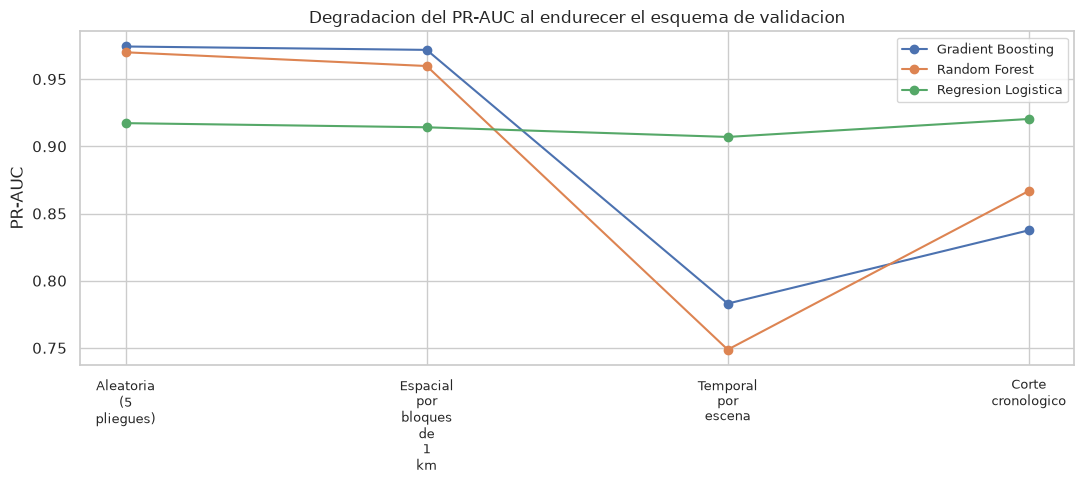

In [19]:
resumen_esquemas = pd.concat([
    validacion.reset_index(),
    temporal.reset_index(),
    cronologico.reset_index(),
])[["validacion", "modelo", "recall", "precision", "f2", "roc_auc", "pr_auc"]]

vista = resumen_esquemas.pivot(index="modelo", columns="validacion", values="pr_auc")
orden = ["Aleatoria (5 pliegues)", "Espacial por bloques de 1 km",
         "Temporal por escena", "Corte cronologico"]
print("PR-AUC por esquema de validacion:\n")
print(vista[orden].round(4).to_string())

fig, eje = plt.subplots(figsize=(11, 5))
vista[orden].T.plot(marker="o", ax=eje)
eje.set(ylabel="PR-AUC", xlabel="",
        title="Degradacion del PR-AUC al endurecer el esquema de validacion")
eje.set_xticks(range(len(orden)))
eje.set_xticklabels([o.replace(" ", "\n") for o in orden], fontsize=9)
eje.legend(fontsize=9)
fig.tight_layout()
plt.show()

**La validación temporal sí hunde el desempeño, y además invierte el ranking de los modelos.**

| Modelo | Aleatoria | Espacial | Temporal por escena | Corte cronológico |
| --- | --- | --- | --- | --- |
| Gradient Boosting | 0.9743 | 0.9718 | **0.7830** | 0.8375 |
| Random Forest | 0.9700 | 0.9598 | **0.7487** | 0.8668 |
| Regresión Logística | 0.9172 | 0.9142 | **0.9070** | 0.9203 |

El Gradient Boosting pierde un 19.6% de PR-AUC al pasar de validación aleatoria a temporal, y el Random Forest un 22.8%. **La Regresión Logística solo pierde un 1.1 %**, y con eso pasa de ser el peor modelo a ser el mejor.

La explicación es la naturaleza de lo que cada modelo aprendió. Los dos modelos de árboles son flexibles y ajustaron umbrales finos sobre los valores de reflectancia de las escenas que vieron; cuando llega una fecha nueva, con otra iluminación, otra atmósfera y otro estado del lago, esos umbrales dejan de estar calibrados. La Regresión Logística, fuertemente regularizada, solo pudo aprender una relación lineal y monótona (más infrarrojo, más riesgo) y esa relación **sí se sostiene entre fechas**.

El corte cronológico añade una dificultad extra que conviene señalar con claridad: las dos fechas con más floración de Amatitlán (2026-04-28 con 37.2% y 2026-06-19 con 53.4%) son también las más recientes. Al entrenar con las 8 fechas antiguas y probar con las 3 recientes, el entrenamiento se queda con 1 110 positivos (0.380% de prevalencia) y la prueba con 3 742 (3.420%), **el 77.1% de los positivos cae en el conjunto de prueba**. El modelo tiene que reconocer floraciones más intensas que cualquiera de las que vio. Que aun así el PR-AUC se mantenga entre 0.84 y 0.92 es una señal razonablemente buena.

**¿Qué esquema da la estimación más realista?** La validación temporal. El uso previsto del modelo es procesar una imagen nueva de una fecha futura, que es exactamente lo que simula agrupar por escena. La validación aleatoria es la menos realista; reparte los 11 registros de un mismo píxel entre entrenamiento y prueba, así que el modelo evalúa píxeles cuya vecindad temporal ya conoce. La validación espacial queda en medio, y en estos datos resulta casi indistinguible de la aleatoria.